# Machine Learning Backtesting Pipeline (TensorFlow & MLflow)
This notebook implements an Expanding Window Time-Series Split, Random Forest (with GridSearchCV), Deep Neural Network (TensorFlow/Keras + KerasTuner), and Decile Sorting Backtesting.
All model training and hyperparameter searches are tracked using MLflow.


In [1]:
import IPython.core.pylabtools
import IPython.core.pylabtools
import os
import sys
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import mlflow
import keras_tuner as kt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Ask TensorFlow to list all available physical GPUs
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ M3 Pro GPU ACTIVATED! Found: {gpu_devices}")
    # Optional: Set memory growth to prevent TF from hoarding all unified memory
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("❌ GPU not found. TensorFlow is falling back to the CPU.")

/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ M3 Pro GPU ACTIVATED! Found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Setup & Data Loading (with MLflow)

In [2]:
# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Spark setup
from dotenv import load_dotenv
os.chdir(os.path.abspath(os.path.join(os.getcwd(), '../../')))
sys.path.append(os.getcwd())

from src.common.setup_spark import create_spark_session
from config.config_spark import Paths

# MLflow Setup
mlflow.set_tracking_uri("sqlite:///mlflow.db") # Local SQLite database for tracking
experiment_name = "SP500_Momentum_Backtest"
mlflow.set_experiment(experiment_name)
print(f"MLflow Experiment set to: {experiment_name}")

spark = create_spark_session()
print("Spark Session created.")

# Load Data
df_gold = spark.read.format("delta").load(Paths.SP500_MOMENTUM_VALUE_PROFITABLE_CRASH_WEEKLY_GOLD)
df_gold.createOrReplaceTempView("gold_prices")

df = df_gold.toPandas()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.weekday

print(f"Data loaded: {df.shape}")
print(f"Years: {df['year'].unique().min()}")


2026-03-17 12:26:51.760 | INFO     | src.common.setup_spark:create_spark_session:19 - 🛠️ Configurant Spark avec le connecteur GCS : https://repo1.maven.org/maven2/com/google/cloud/bigdataoss/gcs-connector/hadoop3-2.2.6/gcs-connector-hadoop3-2.2.6-shaded.jar


MLflow Experiment set to: SP500_Momentum_Backtest


26/03/17 12:26:52 WARN Utils: Your hostname, MacBook-Pro-5.local resolves to a loopback address: 127.0.0.1; using 192.168.1.1 instead (on interface en0)
26/03/17 12:26:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Ivy Default Cache set to: /Users/forget/.ivy2/cache
The jars for the packages stored in: /Users/forget/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-bd007b31-fe35-4daf-bcf0-59330fe2cf20;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.1 in central
	found io.delta#delta-storage;3.2.1 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 65ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.1 from central in [default]
	io.delta#delta-storage;3.2.1 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|   

:: loading settings :: url = jar:file:/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


26/03/17 12:26:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/17 12:26:54 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2026-03-17 12:26:55.579 | SUCCESS  | src.common.setup_spark:create_spark_session:38 - ✅ Spark Session 'SparkApp' créée avec succès ! (Version: 3.5.3)


Spark Session created.


Data loaded: (651491, 136)
Years: 1990


In [3]:
df.describe()

,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,adjClose_GSPC,volume_GSPC,bull_market_ma,bear_market_ma,vix,vix3m,vix_vix3m_ratio,year,month,week
count,651491,651491.000000,6.514910e+05,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,...,651491.000000,6.514910e+05,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000,651491.000000
mean,2011-11-02 23:59:50.584060160,71.058579,7.998621e+06,0.000401,0.000092,-0.004653,-0.003504,-0.003244,-0.000421,0.000159,...,2273.541714,3.166438e+09,0.780487,0.219513,19.241967,16.182398,1.283434,2011.336514,6.548371,3.963917
min,1990-01-05 00:00:00,0.032430,1.000000e+01,-0.088068,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,300.030000,1.499000e+07,0.000000,0.000000,9.140000,5.074201,0.414363,1990.000000,1.000000,0.000000
25%,2004-09-24 00:00:00,13.980000,1.007600e+06,-0.004478,0.000005,-0.504274,-0.502868,-0.502913,-0.500000,-0.498952,...,1144.890000,1.551200e+09,1.000000,0.000000,13.740000,10.799872,1.072941,2004.000000,4.000000,4.000000
50%,2013-04-05 00:00:00,31.180000,2.264200e+06,0.000828,0.000068,-0.004902,-0.003891,-0.001957,0.000000,0.000000,...,1561.800000,3.357690e+09,1.000000,0.000000,17.200000,13.406640,1.266853,2013.000000,7.000000,4.000000
75%,2020-01-03 00:00:00,70.740000,5.217260e+06,0.005640,0.000178,0.493910,0.495542,0.496536,0.498039,0.499044,...,3007.390000,4.233960e+09,1.000000,0.000000,22.370000,19.186553,1.465668,2020.000000,10.000000,4.000000
max,2026-02-20 00:00:00,9924.400000,9.276606e+09,0.092871,0.000328,1.000000,1.000000,1.000000,1.000000,1.000000,...,6966.290000,1.145623e+10,1.000000,1.000000,79.130000,72.057434,2.750128,2026.000000,12.000000,4.000000
std,NaN,196.541643,4.741452e+07,0.010866,0.000087,0.577181,0.577638,0.577274,0.576939,0.577193,...,1593.442257,1.882677e+09,0.413917,0.413917,7.936523,9.147073,0.316211,9.646737,3.461149,0.206369


### Calculate Target Variable: 1-Month Ahead Expected Excess Return

In [4]:
import pandas as pd
import numpy as np

def create_advanced_target(df, period='1YE', top_n=10, pourcentage_target=0.05):
    """
    Crée une cible de classification binaire (0 ou 1).
    Cible = 1 SI l'action est dans le Top N de la semaine 
              ET SI son rendement sur N semaines est strictement supérieur au seuil.
    """
    df = df.copy()
    
    # --- 0. S'assurer des formats et du tri initial ---
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(by=['symbol', 'date'])
    
    # --- 1. Calculer le rendement futur brut ---
    target = df.groupby(['symbol', pd.Grouper(key='date', freq=period)])['adjClose'].last().reset_index()

    target['target_y'] = target.groupby('symbol')['adjClose'].shift(-1) / target['adjClose'] - 1

    target = target.dropna(subset=['target_y'])
    
    # --- 2. Classement Transversal (Cross-Sectional Ranking) ---
    # Pour chaque semaine, on classe les actions. ascending=False met le plus gros rendement en rang 1
    target['rank_cross_sectional'] = target.groupby('date')['target_y'].rank(method='first', ascending=False)
    
    # --- 3. Création de la cible (Classification) ---
    cond_top_n = target['rank_cross_sectional'] <= top_n
    cond_absolute_return = target['target_y'] > pourcentage_target
    
    # L'action reçoit un 1 uniquement si elle remplit les DEUX conditions
    target['target_y'] = (cond_top_n & cond_absolute_return).astype(int)
    
    # --- 4. Nettoyage du dataset final ---
    target = target.drop(columns=['rank_cross_sectional'])
    target = target[['symbol', 'date', 'target_y']]

    df = df.sort_values(by='date')
    target = target.sort_values(by='date')
    
    df = pd.merge_asof(
        df,
        target,
        on='date',
        by='symbol',
        direction='forward'
    )
    
    return df

# Exécution de la fonction (Exemple : Top 10 des actions faisant au moins +5% en 4 semaines)
df = create_advanced_target(df, period='1YE', top_n=50, pourcentage_target=0.15)


In [5]:
df['target_y'].value_counts()

target_y
0.0    554563
1.0     86309
Name: count, dtype: int64

## 4. Algorithm Model Architectures

In [6]:
"""
colonne_list = df.columns.tolist()
colonnes_texte = df.select_dtypes(exclude=['number']).columns.tolist()
colonnes_biais = ['date', 'volume', 'adjClose','symbol', 'workingCapital', 'investedCapital', 'grahamNumber', 'target_y']
features = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)
features = list(features)
print("features :", features)
"""

'\ncolonne_list = df.columns.tolist()\ncolonnes_texte = df.select_dtypes(exclude=[\'number\']).columns.tolist()\ncolonnes_biais = [\'date\', \'volume\', \'adjClose\',\'symbol\', \'workingCapital\', \'investedCapital\', \'grahamNumber\', \'target_y\']\nfeatures = set(colonne_list) - set(colonnes_texte) - set(colonnes_biais)\nfeatures = list(features)\nprint("features :", features)\n'

In [7]:
Valorisation = ['priceToBookRatio', 'priceToSalesRatio', 'priceToEarningsRatio', 'evToEBITDA', 'freeCashFlowYield']
Profitable = ['returnOnEquity', 'returnOnInvestedCapital', 'returnOnAssets', 'grossProfitMargin', 'operatingProfitMargin', 'ebitdaMargin']
Momentum = ['market_return', 'risk_free_rate', 'retvol', 'maxret', 'ill', 'beta', 'mom1w', 'mom1m', 'mom3m', 'mom6m', 'mom12m', 'mom36m', 'mom60m', 'chmom', 'high52', 'dist_ma4', 'dist_ma12', 'dist_ma25', 'dist_ma50']
colonnes_biais = ['date', 'volume', 'adjClose','symbol',  'target_y', 'year']
reduce_features = ['dist_ma50', 'dist_ma4', 'dist_ma12', 'dist_ma25', 'priceToBookRatio', 'returnOnEquity', 'operatingProfitMargin', 'ebitdaMargin', 'dividendYieldPercentage', 'enterpriseValueMultiple', 'evToFreeCashFlow', 'solvencyRatio', 'bottomLineProfitMargin', 'inventoryTurnover', 'daysOfInventoryOutstanding', 'pretaxProfitMargin', 'continuousOperationsProfitMargin', 'workingCapital', 'financialLeverageRatio', 'effectiveTaxRate', 'ebitMargin', 'netProfitMargin', 'operatingCashFlowSalesRatio', 'priceToFairValue' , 'evToSales', 'assetTurnover', 'salesGeneralAndAdministrativeToRevenue', 'returnOnTangibleAssets', 'priceToOperatingCashFlowRatio', 'debtToAssetsRatio', 'evToOperatingCashFlow', 'quickRatio', 'returnOnAssets', 'netDebtToEBITDA', 'cashConversionCycle', 'freeCashFlowOperatingCashFlowRatio', 'investedCapital', 'dividendPerShare', 'bull_market_ma', 'adjClose_GSPC', 'volume_GSPC']
#reduce_features = []

colunms = df.columns.tolist()
string_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Colonnes de type texte :", string_cols)

# 2. Ta logique d'ensembles (sets) était parfaite, on la garde !
# J'ai juste simplifié la soustraction pour que ce soit plus lisible
#features = (set(Valorisation) | set(Profitable) | set(Momentum)) - (set(colonnes_biais) | set(reduce_features))
features = list((set(colunms)) - (set(colonnes_biais) | set(reduce_features) | set(string_cols)))

print("Nombre de features conservées :", len(features))
# print("features :", features)


Colonnes de type texte : ['symbol', 'fiscalYear', 'period', 'reportedCurrency']
Nombre de features conservées : 87


In [8]:
# Define features. Exclude identifiers and target.
print(df.isna().sum())

# Ensure no NaNs in features

df = df.dropna(subset=features)
df = df.reset_index(drop=True)

print(f"Data after target creation: {df.shape}")
print(f"Years: {df['year'].unique().min()}")

symbol                 0
date                   0
adjClose               0
volume                 0
market_return          0
                   ...  
vix_vix3m_ratio        0
year                   0
month                  0
week                   0
target_y           10619
Length: 137, dtype: int64
Data after target creation: (651491, 137)
Years: 1990


## 2. Expanding Window Time-Series Split

In [9]:
def get_classic_train_val_test_splits(df, val_years, test_years):
    """
    Yields a single, classic chronological split (Train -> Val -> Test).
    It splits based on the last N years of your dataset.
    """
    years = sorted(df['year'].unique())
    
    print(f"Total years in dataset: {years[0]} to {years[-1]}")
    
    # Calculate the cutoff years from the end of the dataset
    test_start_year = years[-test_years]
    val_start_year = years[-(test_years + val_years)]
    
    print(f"Train ends before: {val_start_year}")
    print(f"Validation: {val_start_year} to {test_start_year - 1}")
    print(f"Test: {test_start_year} to {years[-1]}")
    
    # 1. Train: Everything before the validation period
    train_idx = df[df['year'] < val_start_year].index
    
    # 2. Validation: The specific validation years
    val_idx = df[(df['year'] >= val_start_year) & (df['year'] < test_start_year)].index
    
    # 3. Test: The final years
    test_idx = df[df['year'] >= test_start_year].index
    
    # Create a label for the test period so your MLflow charts name it correctly
    test_label = test_start_year
    
    # Return as a single-element list so your existing 'for' loop still works perfectly!
    return [(train_idx, val_idx, test_idx, test_label)]

# --- Testing the function ---
splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)

print(f"\nTotal static splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Period: {yr} | Train: {len(tr)} rows | Val: {len(val)} rows | Test: {len(ts)} rows")

Total years in dataset: 1990 to 2026
Train ends before: 2012
Validation: 2012 to 2016
Test: 2017 to 2026

Total static splits: 1
Split 1 | Test Period: 2017 | Train: 298525 rows | Val: 113618 rows | Test: 239348 rows


In [10]:
"""
def get_train_val_test_splits(df, initial_train_years=30, val_years=10, test_years=1):
    
    #Yields train, val, test indices for an expanding window split.
    
    years = sorted(df['year'].unique())

    start_year = years[0]
    
    current_test_year = start_year + initial_train_years + val_years
    print(current_test_year)
    
    splits = []
    
    while current_test_year <= years[-1]:
        train_end = current_test_year - val_years - 1
        val_end = current_test_year - 1
        
        train_idx = df[df['year'] <= train_end].index
        val_idx = df[(df['year'] > train_end) & (df['year'] <= val_end)].index
        test_idx = df[df['year'] == current_test_year].index
        
        splits.append((train_idx, val_idx, test_idx, current_test_year))
        current_test_year += 1
        
    return splits

splits = get_train_val_test_splits(df)
print(f"Total expanding window splits: {len(splits)}")
for i, (tr, val, ts, yr) in enumerate(splits):
    print(f"Split {i+1} | Test Year: {yr} | Train: {len(tr)} | Val: {len(val)} | Test: {len(ts)}")
"""

'\ndef get_train_val_test_splits(df, initial_train_years=30, val_years=10, test_years=1):\n    \n    #Yields train, val, test indices for an expanding window split.\n    \n    years = sorted(df[\'year\'].unique())\n\n    start_year = years[0]\n    \n    current_test_year = start_year + initial_train_years + val_years\n    print(current_test_year)\n    \n    splits = []\n    \n    while current_test_year <= years[-1]:\n        train_end = current_test_year - val_years - 1\n        val_end = current_test_year - 1\n        \n        train_idx = df[df[\'year\'] <= train_end].index\n        val_idx = df[(df[\'year\'] > train_end) & (df[\'year\'] <= val_end)].index\n        test_idx = df[df[\'year\'] == current_test_year].index\n        \n        splits.append((train_idx, val_idx, test_idx, current_test_year))\n        current_test_year += 1\n        \n    return splits\n\nsplits = get_train_val_test_splits(df)\nprint(f"Total expanding window splits: {len(splits)}")\nfor i, (tr, val, ts, yr)

## Reduction Features

In [11]:
splits[0]

(Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
             9,
        ...
        298515, 298516, 298517, 298518, 298519, 298520, 298521, 298522, 298523,
        298524],
       dtype='int64', length=298525),
 Index([298525, 298526, 298527, 298528, 298529, 298530, 298531, 298532, 298533,
        298534,
        ...
        412133, 412134, 412135, 412136, 412137, 412138, 412139, 412140, 412141,
        412142],
       dtype='int64', length=113618),
 Index([412143, 412144, 412145, 412146, 412147, 412148, 412149, 412150, 412151,
        412152,
        ...
        651481, 651482, 651483, 651484, 651485, 651486, 651487, 651488, 651489,
        651490],
       dtype='int64', length=239348),
 2017)

Features supprimées (corrélation > 0.8) : 7
{'forwardPriceToEarningsGrowthRatio', 'interestCoverageRatio', 'grahamNumber', 'returnOnCapitalEmployed', 'taxBurden', 'enterpriseValue', 'vix'}
Dimensions avant PCA : (298525, 80)


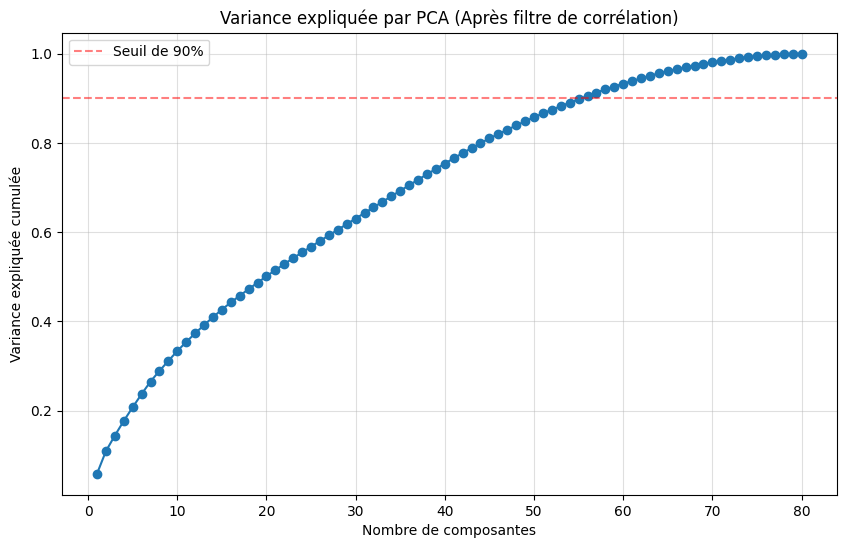

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# On s'assure qu'on a bien des splits
if len(splits) > 0:
    # 1. Récupération de X_train
    train_idx, val_idx, test_idx, test_year = splits[0]
    X_train_df = df.loc[train_idx, features] 
    
    # ---------------------------------------------------------
    # 2. FILTRE DES CORRÉLATIONS
    # ---------------------------------------------------------
    threshold = 0.8
    col_corr = set()
    corr_matrix = X_train_df.corr()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    print(f"Features supprimées (corrélation > {threshold}) : {len(col_corr)}")
    print(col_corr)

    # CORRECTION : On applique VRAIMENT la réduction !
    df_reduced = X_train_df.drop(columns=col_corr)
    print(f"Dimensions avant PCA : {df_reduced.shape}")
    
    # ---------------------------------------------------------
    # 3. SCALING & PCA
    # ---------------------------------------------------------
    scaler = StandardScaler()
    # CORRECTION : On fit le scaler sur df_reduced, pas sur X_train_df
    X_train_scale = scaler.fit_transform(df_reduced) 
    
    pca = PCA()
    pca.fit(X_train_scale)

    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)

    # 4. Affichage
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
    plt.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='Seuil de 90%')
    plt.xlabel("Nombre de composantes")
    plt.ylabel("Variance expliquée cumulée")
    plt.title("Variance expliquée par PCA (Après filtre de corrélation)")
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()
    
else:
    print("Pas assez de données pour le split.")

## Matrix Correlation

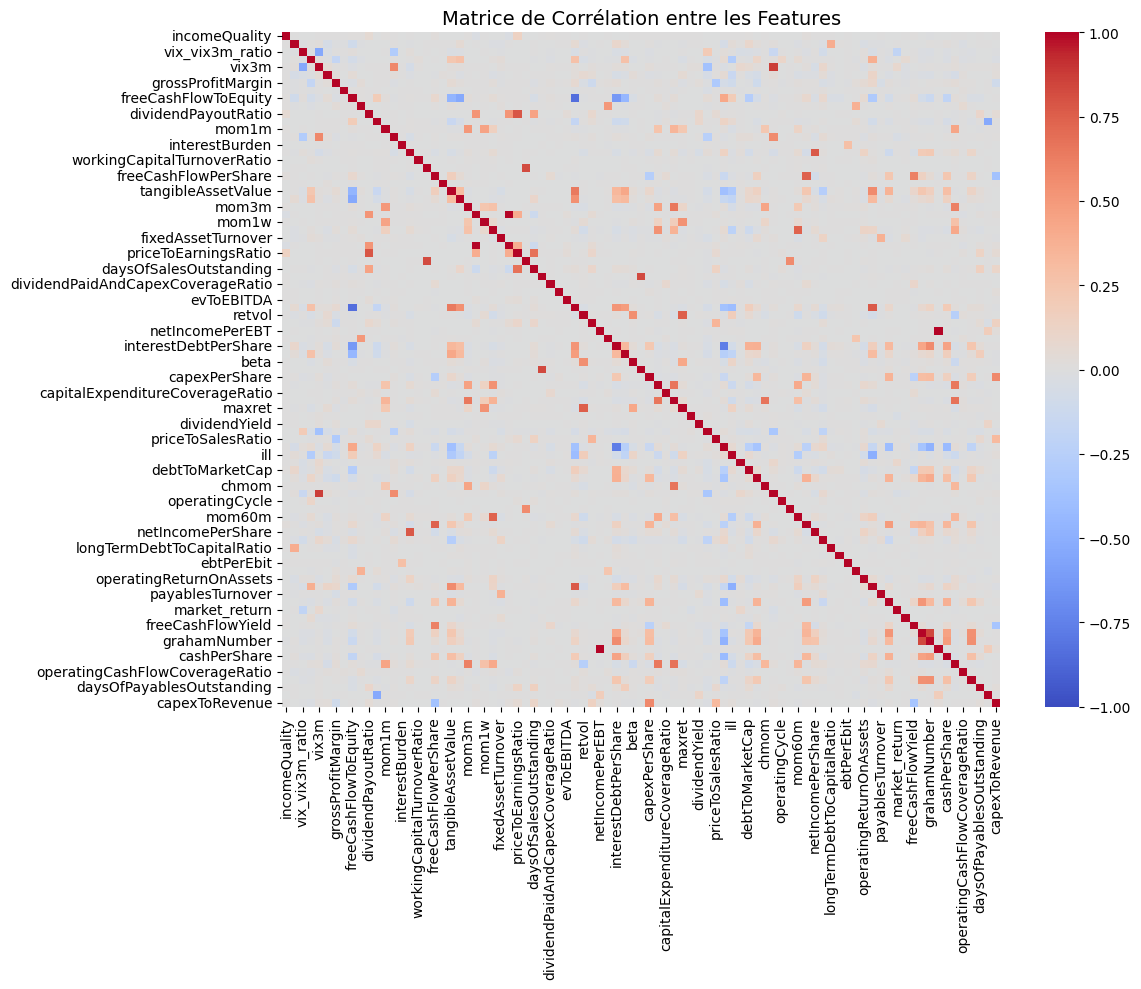


🔥 TOP 20 des paires de variables les plus corrélées :
vix                       vix3m                        0.867636
freeCashFlowToEquity      enterpriseValue             -0.840287
bookValuePerShare         grahamNumber                 0.836048
debtServiceCoverageRatio  interestCoverageRatio        0.829809
priceToFreeCashFlowRatio  returnOnCapitalEmployed      0.823900
priceToEarningsRatio      dividendPayoutRatio          0.788936
earningsYield             netIncomePerShare            0.775874
interestDebtPerShare      grahamNetNet                -0.772897
enterpriseValue           marketCap                    0.768639
retvol                    maxret                       0.752510
freeCashFlowPerShare      operatingCashFlowPerShare    0.749986
mom60m                    mom36m                       0.741057
priceToEarningsRatio      daysOfSalesOutstanding       0.679149
mom6m                     high52                       0.675171
                          chmom                  

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# VISUALISATION DE LA MATRICE DE CORRÉLATION
# ---------------------------------------------------------
plt.figure(figsize=(12, 10)) # Taille ajustable selon le nombre de tes features

# Création de la heatmap
# vmin et vmax forcent l'échelle de -1 (rouge inverse) à 1 (bleu)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0)

plt.title("Matrice de Corrélation entre les Features", fontsize=14)
plt.tight_layout()
plt.show()

# Astuce bonus : Afficher le TOP 10 des paires les plus corrélées (en texte)
print("\n🔥 TOP 20 des paires de variables les plus corrélées :")
corr_pairs = corr_matrix.unstack().sort_values(key=abs, ascending=False)
# On enlève la corrélation de 1.0 (une variable avec elle-même) et on enlève les doublons
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()
print(corr_pairs.head(20))

## 3. Evaluation Metrics ($R^2_{OOS}$)

In [14]:
def calculate_mcc(y_true, y_pred):
    """
    Calcule le Matthews Correlation Coefficient (MCC) pour des classes déséquilibrées.
    
    y_true : array ou liste des vraies étiquettes (0 ou 1)
    y_pred : array ou liste des prédictions de l'IA (0 ou 1)
    """
    # Conversion en arrays numpy pour faciliter les calculs vectoriels
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # 1. Comptage physique de la matrice de confusion
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    # 2. Calcul du Numérateur (La différence croisée)
    numerator = (TP * TN) - (FP * FN)
    
    # 3. Calcul du Dénominateur (Produit des marges)
    # On ajoute un float( ) pour éviter un dépassement de capacité (overflow)
    denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
    
    # 4. Sécurité : Si le dénominateur est 0, le MCC est défini comme 0
    if denominator == 0:
        return 0.0
        
    return numerator / denominator


### Logistic Regression

In [15]:
def train_logistic_regression(X_train_scaled, y_train):
    with mlflow.start_run(run_name="Logistic Regression", nested=True):
        ols = LogisticRegression(class_weight='balanced')
        ols.fit(X_train_scaled, y_train)
        return ols

### XGBoost

In [16]:
def train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="XGBoost", nested=True):
        xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre,n_jobs=-1, random_state=42)
        xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
        return xgb_model

### LightGBM

In [17]:
def train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="LightGBM", nested=True):
        lgbm = lgb.LGBMClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre,n_jobs=-1, random_state=42)
        lgbm.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)])
        return lgbm

### CatBoost

In [18]:
def train_catboost(X_train_scaled, y_train, X_val_scaled, y_val):
    nb_zeros = (y_train == 0).sum()
    nb_uns = (y_train == 1).sum()
    ratio_desequilibre = nb_zeros / nb_uns if nb_uns > 0 else 1.0
    with mlflow.start_run(run_name="CatBoost", nested=True):
        cb = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, scale_pos_weight=ratio_desequilibre, random_seed=42, verbose=False, thread_count=-1)
        cb.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), use_best_model=True)
        return cb

### Random Forest (GridSearchCV + MLflow Autolog)

In [19]:
def train_rf(X_train_scaled, y_train):
    with mlflow.start_run(run_name="RandomForestClassifier", nested=True):
        # On a retiré "scoring='roc_auc'"
        rf = RandomForestClassifier(
            n_estimators=500, 
            max_depth=10, 
            class_weight='balanced_subsample', 
            random_state=42,
            n_jobs=-1 # Petit bonus : ça force ton Mac à utiliser tous ses cœurs pour aller plus vite !
        )
        rf.fit(X_train_scaled, y_train)
        return rf

### Deep Neural Network (KerasTuner + MLflow Autolog + Ensembling)

In [20]:
def build_model(hp, input_dim):
    """KerasTuner model building function"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    # Tune the number of units in the first Dense layer
    hp_units1 = hp.Int('units_1', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units1, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Tune the number of units in the second Dense layer
    hp_units2 = hp.Int('units_2', min_value=8, max_value=32, step=8)
    model.add(layers.Dense(units=hp_units2, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Third hidden layer (fixed small)
    hp_units3 = hp.Int('units_3', min_value=4, max_value=8, step=2)
    model.add(layers.Dense(units=hp_units3, kernel_regularizer=regularizers.l1(1e-5)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    
    # Output layer
    model.add(layers.Dense(1, 'sigmoid'))
    
    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc')])
    return model

def train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=5, epochs=100, patience=5):
    mlflow.tensorflow.autolog(disable=True) 
    
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    input_dim = X_train_scaled.shape[1]

    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    total = neg + pos
    
    # Formule standard de Keras pour équilibrer parfaitement les gradients
    weight_for_0 = (1 / neg) * (total / 2.0)
    weight_for_1 = (1 / pos) * (total / 2.0)
    class_weight_dict = {0: weight_for_0, 1: weight_for_1}
    
    print(f"Poids des classes : 0 -> {weight_for_0:.2f} | 1 -> {weight_for_1:.2f}") 
    
    # ==========================================
    # 🚀 THE MLOPS FIX: tf.data PIPELINE
    # ==========================================
    batch_size = 32768 # You can increase this to 512 or 1024 if VRAM allows
    
    # 1. Train Dataset: Shuffle, Batch, Cache, and Prefetch
    train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train.values))
    train_dataset = train_dataset.shuffle(buffer_size=len(X_train_scaled)) \
                                 .batch(batch_size) \
                                 .cache() \
                                 .prefetch(tf.data.AUTOTUNE)
                                 
    # 2. Validation Dataset: Batch, Cache, and Prefetch (No need to shuffle val data)
    val_dataset = tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val.values))
    val_dataset = val_dataset.batch(batch_size) \
                             .cache() \
                             .prefetch(tf.data.AUTOTUNE)
    # ==========================================

    print("Starting KerasTuner RandomSearch...")
    with tf.device('/CPU:0'):
        tuner = kt.RandomSearch(
            lambda hp: build_model(hp, input_dim),
            objective=kt.Objective('val_auc', direction='max'), # On cible val_auc vers le haut
            max_trials=5,     
            directory='keras_tuner_dir',
            project_name='momentum_dnn',
            overwrite=True
        )
    
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_auc', 
            mode='max', 
            patience=patience, 
            restore_best_weights=True
        )
        
        # On passe le class_weight au Tuner pour qu'il cherche les meilleurs HP en tenant compte du déséquilibre
        tuner.search(train_dataset, epochs=30, validation_data=val_dataset, 
                     callbacks=[early_stopping], class_weight=class_weight_dict, verbose=0)
        
        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        print(f"Best HPs found: Layer1: {best_hps.get('units_1')}, Layer2: {best_hps.get('units_2')}, LR: {best_hps.get('learning_rate')}")
        
    models = []
    mlflow.tensorflow.autolog() 
    
    for i in range(num_models):
        with mlflow.start_run(run_name=f"DNN_Ensemble_Member_{i+1}", nested=True):
            mlflow.log_params(best_hps.values)
            tf.random.set_seed(42 + i)
            
            model = tuner.hypermodel.build(best_hps)
            
            # Use the pre-built tf.data pipeline for blazing fast training
            history = model.fit(
                train_dataset,
                epochs=epochs,
                validation_data=val_dataset,
                callbacks=[early_stopping],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            print(f"Trained DNN component {i+1}/{num_models} - Best Val Loss: {val_loss:.6f}")
            models.append(model)
        
    return models

def predict_dnn_ensemble(models, scaler, X_test):
    X_test_scaled = scaler.transform(X_test)
    
    # Create a fast prediction pipeline
    test_dataset = tf.data.Dataset.from_tensor_slices(X_test_scaled)
    test_dataset = test_dataset.batch(32768).cache().prefetch(tf.data.AUTOTUNE)
    
    preds = []
    for model in models:
        # Pass the dataset to predict
        pred = model.predict(test_dataset, verbose=0).flatten()
        preds.append(pred)
        
    return np.mean(preds, axis=0)



## 5. Backtesting Portfolio Construction (Decile Sorting)

In [21]:
def backtest_portfolio(test_df, predictions_col, transaction_cost=0.001, top_n=10):
    """
    Simulates a Long-Only portfolio with dynamic transaction costs.
    Invests strictly in the Top N performing stocks based on predictions_col.
    """
    results = []
    
    # CRITICAL FIX 1: Sort dataframe before shift(-1)
    test_df = test_df.copy()
    test_df['date'] = pd.to_datetime(test_df['date'])
    test_df = test_df.sort_values(by=['symbol', 'date'])
    
    # Calculate future return
    test_df['return+1'] = test_df.groupby('symbol')['adjClose'].shift(-1) / test_df['adjClose'] - 1
    
    # 🛠️ CORRECTION 1 : On supprime la dernière ligne vide pour éviter les NaN
    test_df = test_df.dropna(subset=['return+1'])
    
    prev_long_symbols = set()

    for date, week_data in test_df.groupby('date'):
        if len(week_data) < top_n: 
            continue
            
        week_data = week_data.copy()
        
        # --- 1. BENCHMARK CALCULATION ---
        if 'dollar_volume' not in week_data.columns:
            week_data['dollar_volume'] = week_data['volume'] * week_data['adjClose']
            
        universe_weights = week_data['dollar_volume'] / week_data['dollar_volume'].sum()
        benchmark_return = np.sum(universe_weights * week_data['return+1'])
        
        # --- 2. PORTFOLIO TOP N (LONG ONLY) ---
        try:
            # 1. On garde uniquement les actions où l'IA est confiante (> 50%)
            valid_stocks = week_data[week_data[predictions_col] >= 0.5].copy()
            
            # 2. On trie par la probabilité la plus forte (Le "Top Confiance")
            valid_stocks = valid_stocks.sort_values(by=predictions_col, ascending=False)
            
            # 3. On prend strictement le Top N (ou moins, s'il n'y a pas assez d'actions valides)
            long_portfolio = valid_stocks.head(top_n)
            
            curr_long_symbols = set(long_portfolio['symbol'])
            num_l = len(curr_long_symbols)
            
            if num_l > 0:
                # 4. Équipondération : On répartit 100% du capital sur les actions sélectionnées
                gross_portfolio_return = long_portfolio['return+1'].mean()
                
                # --- 3. DYNAMIC TRANSACTION COSTS (TURNOVER) ---
                new_longs = curr_long_symbols - prev_long_symbols
                
                # Turnover calculé sur la base du nombre d'actions réellement en portefeuille
                turnover_long = len(new_longs) / num_l 
                
                cost_long = turnover_long * transaction_cost * 2
                net_portfolio_return = gross_portfolio_return - cost_long
                
                prev_long_symbols = curr_long_symbols
            else:
                # L'IA est pessimiste partout (< 0.5). On se protège en restant 100% en Cash.
                gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
                prev_long_symbols = set()
                
        except Exception as e:
            print(f"❌ Erreur à la date {date} : {e}")
            gross_portfolio_return, net_portfolio_return, turnover_long, num_l = 0, 0, 0, 0
            prev_long_symbols = set()
            
        # Append results for this week
        results.append({
            'date': date,
            'gross_return': gross_portfolio_return,
            'portfolio_return': net_portfolio_return,
            'benchmark_return': benchmark_return,
            'turnover_pct': turnover_long,
            'num_long': num_l
        })
            
    bt_df = pd.DataFrame(results)

    # --- METRICS CALCULATION ---
    if bt_df.empty:
        return bt_df, {}
        
    bt_df['date'] = pd.to_datetime(bt_df['date'])
    bt_df = bt_df.dropna(subset=['portfolio_return'])
    
    bt_df['cum_return'] = (1 + bt_df['portfolio_return']).cumprod()
    bt_df['cum_benchmark'] = (1 + bt_df['benchmark_return']).cumprod()
    bt_df['outperformance'] = bt_df['cum_return'] - bt_df['cum_benchmark']

    n_years = bt_df['date'].dt.year.nunique()
    
    total_ret = bt_df['cum_return'].iloc[-1] - 1
    cagr = (bt_df['cum_return'].iloc[-1]) ** (1 / max(1, n_years)) - 1
    mean_ret = bt_df['portfolio_return'].mean()
    std_ret = bt_df['portfolio_return'].std()
    sharpe = ((mean_ret / std_ret) * np.sqrt(52)) if std_ret > 0 else 0
    max_dd = ((bt_df['cum_return'] - bt_df['cum_return'].cummax()) / bt_df['cum_return'].cummax()).min()

    bench_total_ret = bt_df['cum_benchmark'].iloc[-1] - 1
    bench_cagr = (bt_df['cum_benchmark'].iloc[-1]) ** (1 / max(1, n_years)) - 1 if n_years > 0 and bt_df['cum_benchmark'].iloc[-1] > 0 else 0
    bench_mean = bt_df['benchmark_return'].mean()
    bench_std = bt_df['benchmark_return'].std()
    bench_sharpe = (bench_mean / bench_std) * np.sqrt(52) if bench_std > 0 else 0
    bench_max_dd = ((bt_df['cum_benchmark'] - bt_df['cum_benchmark'].cummax()) / bt_df['cum_benchmark'].cummax()).min()
        
    metrics = {
        'Total_Return': total_ret,
        'CAGR': cagr,
        'Sharpe_Ratio': sharpe,
        'Max_Drawdown': max_dd,
        'Bench_Total_Return': bench_total_ret,
        'Bench_CAGR': bench_cagr,
        'Bench_Sharpe': bench_sharpe,
        'Bench_Max_Drawdown': bench_max_dd
    }
    
    return bt_df, metrics

## 6. Run the Pipeline over the Expanding Window

In [22]:
if len(splits) > 0:

    print("🧹 Nettoyage des données avant l'entraînement...")

    df = df.replace([np.inf, -np.inf], np.nan)
    # On s'assure de ne pas avoir de NaN sur nos cibles
    df = df.dropna(subset=['target_y'])
    df = df.dropna(subset=features)
    df = df.reset_index(drop=True)

    print(f"✅ Nettoyage terminé. Taille du dataset : {df.shape}")

    splits = get_classic_train_val_test_splits(df, val_years=5, test_years=10)
    
    print(f"🚀 Lancement du Walk-Forward Backtest sur {len(splits)} années...")
    
    all_oos_results = []

    STRATEGY_FREQ = "weekly"
    TRANS_COST = 0.001
    DNN_EPOCHS = 100
    DNN_MODELS = 5
    TARGET_FREQ = "1 an fixe"
    NUM_SPLITS = 10
    TOP = 10
    NOTES = "Test final de Classification. Comparaison de 6 Modèles avec MCC et PSR."

    mlflow.set_experiment("Maximize_CAGR_SP500")
    run_name = f"Test_{STRATEGY_FREQ}_MultiModels_Target{TARGET_FREQ}_Top{TOP}"
    model_keys = ['dnn', 'rf', 'lr', 'xgboost', 'lightgbm', 'catboost']

    with mlflow.start_run(run_name="CAGR_Forward_Backtest_Multi") as parent_run:

        mlflow.set_tag("Frequency", "Weekly")
        mlflow.log_params({
            "frequency": STRATEGY_FREQ,
            "features_count": len(features),
            "transaction_cost": TRANS_COST,
            "target_freq": TARGET_FREQ,
            "top": TOP,
            "num_splits": NUM_SPLITS,
            "notes": NOTES
        })
        
        # =========================================================
        # 1. LA BOUCLE SUR TOUTES LES ANNÉES
        # =========================================================
        for i, (train_idx, val_idx, test_idx, test_year) in enumerate(splits):
            print(f"\n--- Traitement de l'Année de Test {test_year} ({i+1}/{len(splits)}) ---")
            
            # 🛠️ CORRECTION : Utilisation de target_y pour l'entraînement
            X_train, y_train = df.loc[train_idx, features], df.loc[train_idx, 'target_y']
            X_val, y_val = df.loc[val_idx, features], df.loc[val_idx, 'target_y']
            X_test, y_test = df.loc[test_idx, features], df.loc[test_idx, 'target_y']
            
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            X_test_scaled = scaler.transform(X_test)
            
            # --- ENTRAÎNEMENTS ---
            print("  -> Training DNN...")
            dnn_models = train_dnn_ensemble(X_train, y_train, X_val, y_val, scaler, num_models=DNN_MODELS, epochs=DNN_EPOCHS, patience=3)
            
            print("  -> Training ML Models...")
            rf_model = train_rf(X_train_scaled, y_train)
            lr_model = train_logistic_regression(X_train_scaled, y_train)
            xgboost_model = train_xgboost(X_train_scaled, y_train, X_val_scaled, y_val)
            lightgbm_model = train_lightgbm(X_train_scaled, y_train, X_val_scaled, y_val)
            catboost_model = train_catboost(X_train_scaled, y_train, X_val_scaled, y_val)
            
            # --- PRÉDICTIONS GROUPÉES ---
            preds_dict = {
                'dnn': predict_dnn_ensemble(dnn_models, scaler, X_test),
                'rf': rf_model.predict_proba(X_test_scaled)[:, 1],
                'lr': lr_model.predict_proba(X_test_scaled)[:, 1],
                'xgboost': xgboost_model.predict_proba(X_test_scaled)[:, 1],
                'lightgbm': lightgbm_model.predict_proba(X_test_scaled)[:, 1],
                'catboost': catboost_model.predict_proba(X_test_scaled)[:, 1]
            }
            
            test_df_year = df.loc[test_idx].copy()
            mcc_year_dict = {}
            
            # --- SUIVI ANNÉE PAR ANNÉE ---
            for model_name, preds_proba in preds_dict.items():
                preds_binary = (preds_proba >= 0.5).astype(int)
                mcc_year = float(calculate_mcc(y_test.values, preds_binary))
                mcc_year_dict[model_name] = mcc_year
                
                mlflow.log_metric(f"Yearly_{model_name.upper()}_MCC_OOS", mcc_year, step=int(test_year))
                test_df_year[f'{model_name}_pred'] = preds_proba
                
            # 🛠️ CORRECTION : Print propre avec les scores MCC
            print(f"  -> MCC {test_year} | DNN: {mcc_year_dict['dnn']:.4f} | XGB: {mcc_year_dict['xgboost']:.4f} | LGBM: {mcc_year_dict['lightgbm']:.4f}")
            
            all_oos_results.append(test_df_year)
            
        # =========================================================
        # 2. L'ASSEMBLAGE (Le vrai Backtest Global)
        # =========================================================
        print("\n" + "="*50)
        print("🔗 Assemblage des prédictions et calcul des Backtests...")
        
        final_test_df = pd.concat(all_oos_results).sort_values(['symbol', 'date'])
        
        csv_path = "final_predictions.csv"
        final_test_df.to_csv(csv_path, index=False)
        mlflow.log_artifact(csv_path)
        
        final_metrics = {}
        
        for model_name in model_keys:
            pred_col = f'{model_name}_pred'
            
            # 🛠️ CORRECTION : MCC Global au lieu du R2
            global_preds_binary = (final_test_df[pred_col].values >= 0.5).astype(int)
            mcc_global = float(calculate_mcc(final_test_df['target_y'].values, global_preds_binary))
            mlflow.log_metric(f"Global_{model_name.upper()}_MCC_OOS", mcc_global)
            
            # Backtest
            print(f"Running Backtest for {model_name.upper()}...")
            bt_df, metrics = backtest_portfolio(final_test_df, pred_col, transaction_cost=TRANS_COST, top_n=TOP)
            
            if not bt_df.empty:
                mlflow.log_metrics({f"{model_name.upper()}_{k}": float(v) for k, v in metrics.items()})
                final_metrics[model_name.upper()] = metrics
            else:
                print(f"  ⚠️ Backtest vide pour {model_name.upper()}.")

        # =========================================================
        # 3. AFFICHAGE DU TABLEAU COMPARATIF FINAL
        # =========================================================
        if final_metrics:
            metrics_table_data = {
                "Métrique": [
                    "Total Return", 
                    "CAGR (Annualisé)", 
                    "Sharpe Ratio", 
                    "Max Drawdown",
                    "Probabilité Overfitting"
                ]
            }
            
            first_model = list(final_metrics.keys())[0]
            metrics_table_data["S&P 500 (Benchmark)"] = [
                f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
                f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
                f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%",
                "N/A"
            ]

            for model_name, metrics in final_metrics.items():
                metrics_table_data[model_name] = [
                    f"{metrics['Total_Return']*100:.2f}%", 
                    f"{metrics['CAGR']*100:.2f}%", 
                    f"{metrics['Sharpe_Ratio']:.2f}", 
                    f"{metrics['Max_Drawdown']*100:.2f}%",
                    f"{metrics.get('Prob_Overfitting', 0)*100:.2f}%"
                ]
                
            metrics_table = pd.DataFrame(metrics_table_data)
            
            print("\n" + "="*120)
            print("📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)")
            print("="*120)
            print(metrics_table.to_string(index=False))
            print("="*120 + "\n")
            
            with open("performance_metrics.txt", "w") as f:
                f.write(metrics_table.to_string(index=False))
            mlflow.log_artifact("performance_metrics.txt")
            
else:
    print("Not enough data to form a split. Check your timeframe.")


🧹 Nettoyage des données avant l'entraînement...
✅ Nettoyage terminé. Taille du dataset : (640872, 137)
Total years in dataset: 1990 to 2025
Train ends before: 2011
Validation: 2011 to 2015
Test: 2016 to 2025
🚀 Lancement du Walk-Forward Backtest sur 1 années...

--- Traitement de l'Année de Test 2016 (1/1) ---
  -> Training DNN...
Poids des classes : 0 -> 0.61 | 1 -> 2.85


2026-03-17 12:27:38.765227: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-03-17 12:27:38.765261: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-03-17 12:27:38.765270: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1773746858.765283  245284 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1773746858.765305  245284 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Starting KerasTuner RandomSearch...
Best HPs found: Layer1: 32, Layer2: 16, LR: 0.01


2026-03-17 12:27:59.102071: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-17 12:27:59.131555: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-03-17 12:27:59.543521: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


...

Running Backtest for LR...
Running Backtest for XGBOOST...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11146/4045215667.py:23: RuntimeWarning: overflow encountered in scalar multiply
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11146/4045215667.py:23: RuntimeWarning: invalid value encountered in sqrt
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))


Running Backtest for LIGHTGBM...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11146/4045215667.py:23: RuntimeWarning: overflow encountered in scalar multiply
  denominator = np.sqrt(float((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))


Running Backtest for CATBOOST...

📊 TABLEAU DES PERFORMANCES FINALES (MULTI-MODÈLES vs BENCHMARK)
               Métrique S&P 500 (Benchmark)     DNN      RF      LR XGBOOST LIGHTGBM CATBOOST
           Total Return             385.05% 775.19% 724.02% 413.04% 363.50%  596.86% 1920.39%
       CAGR (Annualisé)              17.11%  24.23%  23.48%  17.76%  16.57%   21.43%   35.07%
           Sharpe Ratio                0.89    0.72    0.78    0.67    0.61     0.75     1.13
           Max Drawdown             -33.00% -59.46% -46.61% -46.48% -59.60%  -58.13%  -42.93%
Probabilité Overfitting                 N/A   0.00%   0.00%   0.00%   0.00%    0.00%    0.00%



## 7. Visualisation results

🚀 Lancement des backtests pour tous les modèles...
  -> Backtest en cours pour DNN...
  -> Backtest en cours pour Random Forest...
  ❌ Colonne ols_pred introuvable. Modèle ignoré.
  ❌ Colonne lasso_pred introuvable. Modèle ignoré.
  ❌ Colonne ridge_pred introuvable. Modèle ignoré.
  -> Backtest en cours pour XGBoost...
  -> Backtest en cours pour LightGBM...
  -> Backtest en cours pour CatBoost...

📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)
        Métrique S&P 500 (Benchmark)     DNN Random Forest XGBoost LightGBM CatBoost
    Total Return             385.05% 775.19%       724.02% 363.50%  596.86% 1920.39%
CAGR (Annualisé)              17.11%  24.23%        23.48%  16.57%   21.43%   35.07%
    Sharpe Ratio                0.89    0.72          0.78    0.61     0.75     1.13
    Max Drawdown             -33.00% -59.46%       -46.61% -59.60%  -58.13%  -42.93%



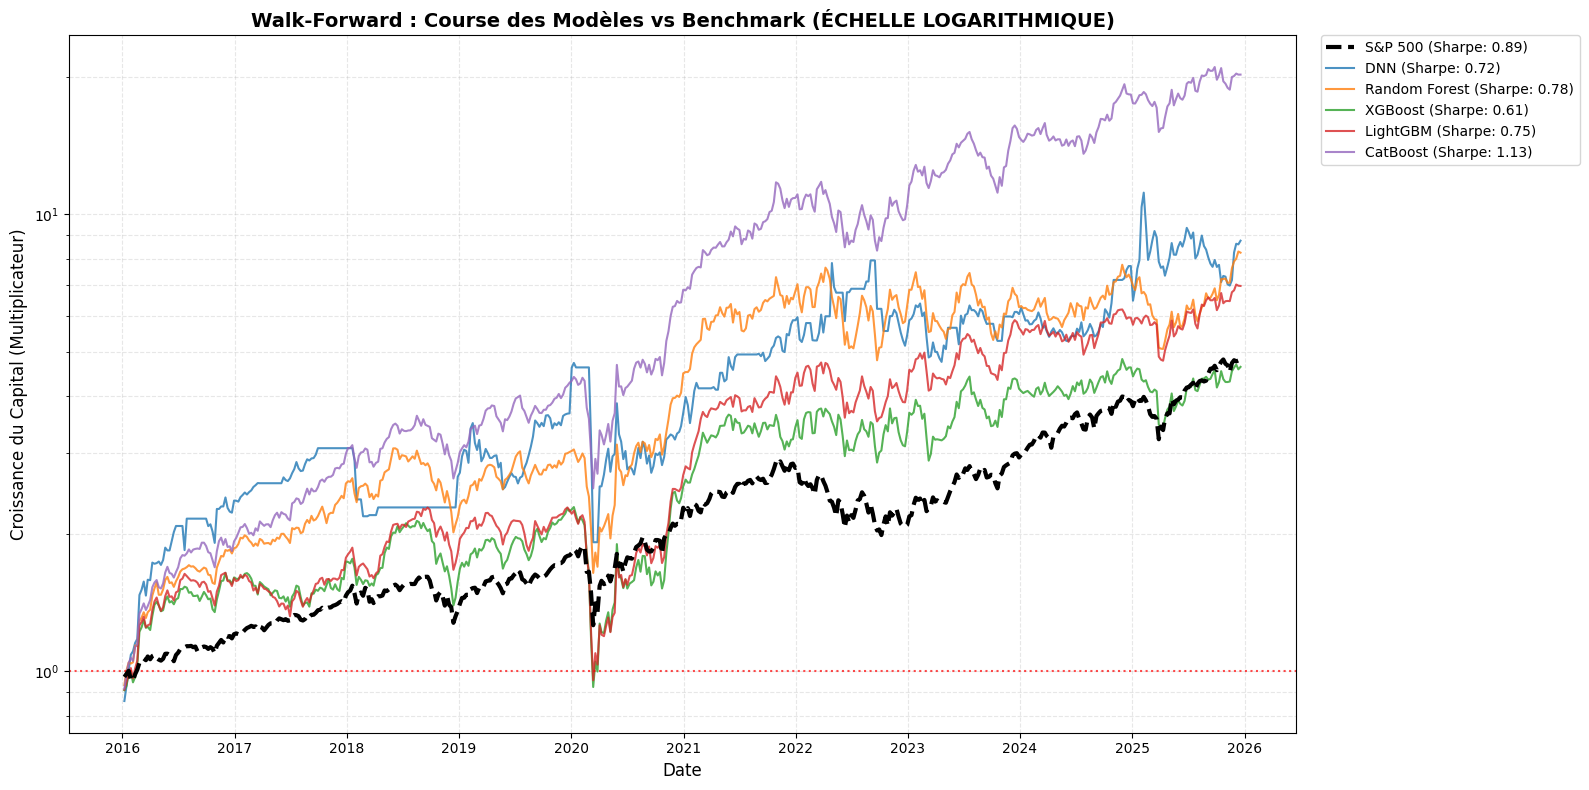

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

print("🚀 Lancement des backtests pour tous les modèles...")

# 1. On liste tous les modèles et leurs colonnes de prédictions correspondantes
models_to_test = {
    'DNN': 'dnn_pred',
    'Random Forest': 'rf_pred',
    'OLS': 'ols_pred',
    'Lasso': 'lasso_pred',
    'Ridge': 'ridge_pred',
    'XGBoost': 'xgboost_pred',
    'LightGBM': 'lightgbm_pred',
    'CatBoost': 'catboost_pred'
}

# On initialise nos fameux dictionnaires !
all_bt_df = {}
final_metrics = {}

# 2. On boucle pour calculer le backtest de chaque modèle
for model_name, pred_col in models_to_test.items():
    # On vérifie par sécurité que la colonne existe bien dans final_test_df
    if pred_col in final_test_df.columns:
        print(f"  -> Backtest en cours pour {model_name}...")
        bt_df, metrics = backtest_portfolio(final_test_df, pred_col, transaction_cost=0.001, top_n=10)
        
        # Si le backtest a fonctionné, on le stocke
        if not bt_df.empty:
            all_bt_df[model_name] = bt_df
            final_metrics[model_name] = metrics
        else:
            print(f"  ⚠️ Le backtest pour {model_name} est vide.")
    else:
        print(f"  ❌ Colonne {pred_col} introuvable. Modèle ignoré.")

# Si on a au moins un modèle réussi, on passe à l'affichage
if final_metrics:
    
    # ==========================================
    # 3. TABLEAU DES PERFORMANCES MULTI-MODÈLES
    # ==========================================
    metrics_table_data = {
        "Métrique": ["Total Return", "CAGR (Annualisé)", "Sharpe Ratio", "Max Drawdown"]
    }
    
    # Ajout du Benchmark (S&P 500) en premier
    first_model = list(final_metrics.keys())[0]
    metrics_table_data["S&P 500 (Benchmark)"] = [
        f"{final_metrics[first_model]['Bench_Total_Return']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_CAGR']*100:.2f}%", 
        f"{final_metrics[first_model]['Bench_Sharpe']:.2f}", 
        f"{final_metrics[first_model]['Bench_Max_Drawdown']*100:.2f}%"
    ]

    # Ajout de tous les modèles
    for model_name, metrics in final_metrics.items():
        metrics_table_data[model_name] = [
            f"{metrics['Total_Return']*100:.2f}%", 
            f"{metrics['CAGR']*100:.2f}%", 
            f"{metrics['Sharpe_Ratio']:.2f}", 
            f"{metrics['Max_Drawdown']*100:.2f}%"
        ]
        
    metrics_table = pd.DataFrame(metrics_table_data)
    
    print("\n" + "="*120)
    print("📊 TABLEAU DES PERFORMANCES FINALES (TOP 5 - FRAIS 0.1%)")
    print("="*120)
    print(metrics_table.to_string(index=False))
    print("="*120 + "\n")

    # ==========================================
    # 4. GRAPHIQUE MULTI-COURBES (ÉCHELLE LOG)
    # ==========================================
    fig, ax1 = plt.subplots(figsize=(16, 8))

    # On trace la courbe du S&P 500 (Benchmark) en noir épais
    first_bt = list(all_bt_df.values())[0]
    bench_sharpe = final_metrics[first_model]['Bench_Sharpe']
    ax1.plot(first_bt['date'], first_bt['cum_benchmark'], label=f"S&P 500 (Sharpe: {bench_sharpe:.2f})", color='black', linestyle='--', linewidth=3, zorder=10)

    # On trace les courbes de tous les modèles IA
    for model_name, bt_data in all_bt_df.items():
        sharpe = final_metrics[model_name]['Sharpe_Ratio']
        # Les modèles avec un bon Sharpe auront tendance à se démarquer visuellement
        ax1.plot(bt_data['date'], bt_data['cum_return'], label=f"{model_name} (Sharpe: {sharpe:.2f})", linewidth=1.5, alpha=0.8)

    # Ligne de base (Capital de départ)
    ax1.axhline(y=1.0, color='red', linestyle=':', alpha=0.7)
    
    # Paramètres d'affichage
    ax1.set_yscale('log')
    ax1.set_title('Walk-Forward : Course des Modèles vs Benchmark (ÉCHELLE LOGARITHMIQUE)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Croissance du Capital (Multiplicateur)', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    
    # On met la légende à l'extérieur pour ne pas cacher les courbes
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0., fontsize=10) 
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("❌ Tous les backtests ont échoué ou sont vides.")
          

🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11146/4159876748.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)


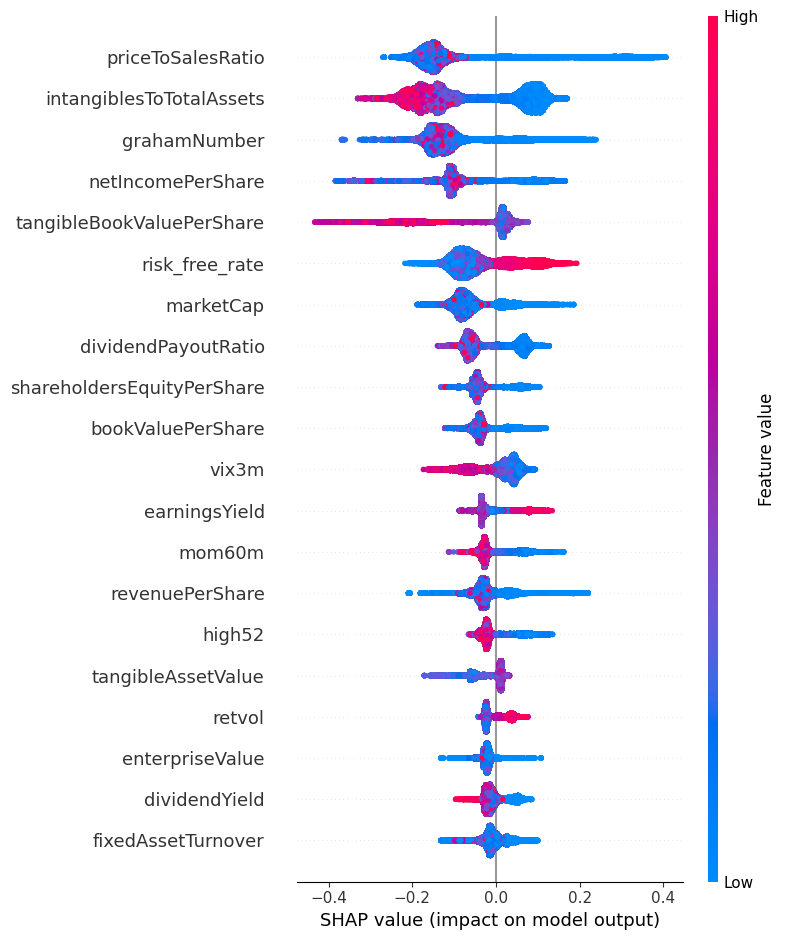

In [24]:
import shap
import matplotlib.pyplot as plt

print("🧠 Calcul des valeurs SHAP (Cela peut prendre quelques secondes)...")

# 1. Création de l'explainer (Le "scanner" de cerveau pour LightGBM)
explainer = shap.TreeExplainer(catboost_model)

# 2. On calcule les valeurs SHAP sur ton dernier jeu de test
# ⚠️ Attention : on utilise X_test_scaled car le modèle a appris sur des données scalées !
shap_values = explainer.shap_values(X_test_scaled)

# 3. Gestion de la structure de sortie (Classification Binaire)
# Selon la version de LightGBM/SHAP, la sortie peut être une liste contenant [valeurs_pour_0, valeurs_pour_1]
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1] # On regarde l'impact pour la classe 1 (Les "gagnants")
else:
    shap_vals_to_plot = shap_values

# 4. Affichage du graphique magique
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_to_plot, X_test_scaled, feature_names=features)

⚡ Calcul des SHAP sur un échantillon (Version Rapide)...


/var/folders/6k/82j2nnl13hj9ld7nmzpdt6fh0000gn/T/ipykernel_11146/3170964639.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features)


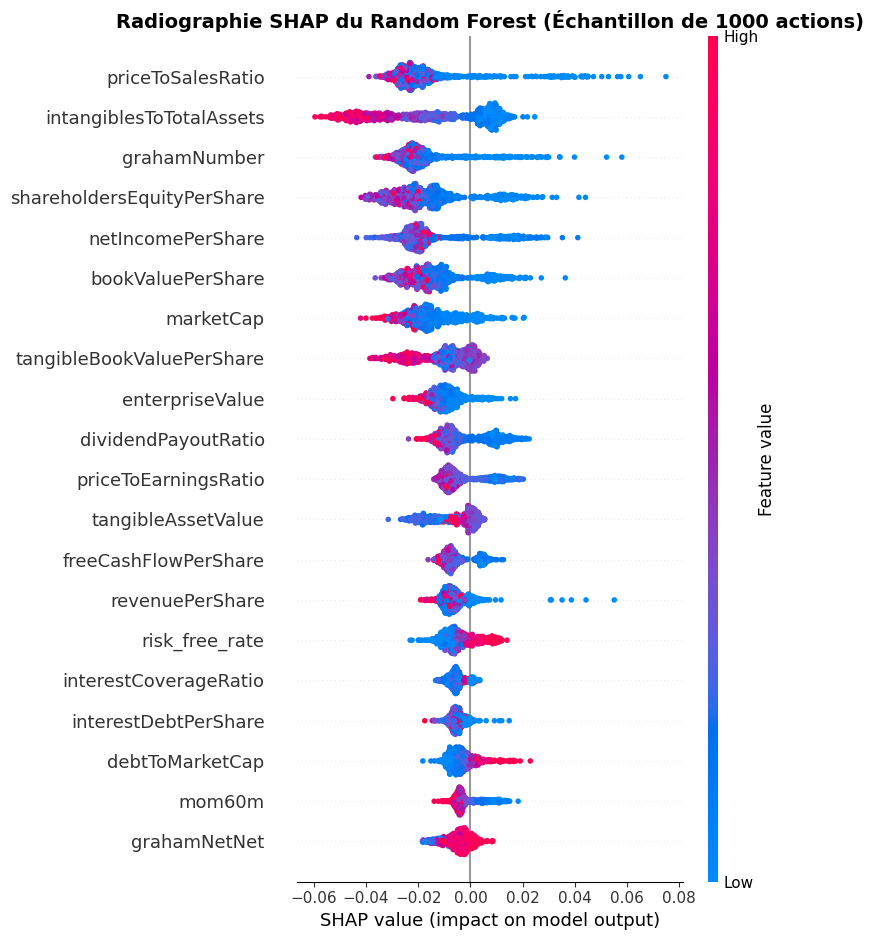

In [25]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚡ Calcul des SHAP sur un échantillon (Version Rapide)...")

# 1. LA MAGIE : On prend un échantillon de 1000 lignes au hasard
taille_echantillon = min(1000, X_test_scaled.shape[0])
indices_aleatoires = np.random.choice(X_test_scaled.shape[0], size=taille_echantillon, replace=False)
X_test_sample = X_test_scaled[indices_aleatoires]

# 2. On recrée l'explainer
explainer_rf = shap.TreeExplainer(rf_model)

# 3. On calcule UNIQUEMENT sur l'échantillon (Ça va prendre 5 secondes au lieu de 20 minutes !)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

# 4. Formatage de la sortie (identique à avant)
if isinstance(shap_values_rf, list):
    shap_vals_rf_to_plot = shap_values_rf[1]
elif len(shap_values_rf.shape) == 3:
    shap_vals_rf_to_plot = shap_values_rf[:, :, 1]
else:
    shap_vals_rf_to_plot = shap_values_rf

# 5. Affichage
plt.figure(figsize=(10, 8))
plt.title("Radiographie SHAP du Random Forest (Échantillon de 1000 actions)", fontsize=14, fontweight='bold')
# Attention : on donne bien X_test_sample au graphique pour que les couleurs correspondent !
shap.summary_plot(shap_vals_rf_to_plot, X_test_sample, feature_names=features)

In [26]:
final_test_df

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,year,month,week,target_y,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred
385669,A,2016-01-08,35.64,3736768,-0.010838,0.000008,0.438972,-0.152034,0.293362,0.541756,...,2016,1,4,0.0,0.331509,0.222511,0.374905,0.188929,0.127677,0.293718
386202,A,2016-01-15,34.27,2994400,-0.021599,0.000010,0.070664,0.177730,0.477516,0.216274,...,2016,1,4,0.0,0.321626,0.215009,0.349533,0.172384,0.128214,0.275417
386446,A,2016-01-22,35.07,1834500,0.020284,0.000012,-0.764957,-0.311966,-0.106838,-0.440171,...,2016,1,4,0.0,0.223418,0.207865,0.311674,0.172384,0.123665,0.265597
387088,A,2016-01-29,34.77,2959900,0.024760,0.000013,0.235043,0.534188,0.440171,0.004274,...,2016,1,4,0.0,0.312050,0.210289,0.337775,0.174632,0.116381,0.271945
387287,A,2016-02-05,33.28,4424609,-0.018481,0.000012,-0.147122,-0.718550,0.194030,0.215352,...,2016,2,4,0.0,0.270780,0.212892,0.304306,0.131870,0.093835,0.266536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638332,ZTS,2025-11-28,127.64,2143000,0.005355,0.000154,0.608445,0.765835,-0.451056,0.358925,...,2025,11,4,0.0,0.366487,0.239705,0.502620,0.070157,0.050065,0.284723
639143,ZTS,2025-12-05,118.15,4279887,0.001934,0.000147,-0.823755,-0.992337,-0.245211,-0.823755,...,2025,12,4,0.0,0.279381,0.240834,0.414690,0.064127,0.049918,0.268368
639468,ZTS,2025-12-12,118.16,5071179,-0.010664,0.000144,-0.080769,-0.044146,-0.474088,-0.365385,...,2025,12,4,0.0,0.354078,0.237177,0.467396,0.063636,0.049931,0.254228
640193,ZTS,2025-12-19,121.72,11297564,0.008818,0.000144,0.055662,0.443378,-0.631478,-0.071017,...,2025,12,4,0.0,0.352687,0.237761,0.483443,0.056433,0.045368,0.268368


In [27]:
final_test_df[final_test_df['rf_pred'] == 1].sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,year,month,week,target_y,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred


In [28]:
final_test_df[final_test_df['date'] == '2023-01-06'].sort_values(by='target_y', ascending=False).head(10)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,year,month,week,target_y,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred
562814,ISRG,2023-01-06,270.39,1659500,0.022841,0.000185,-0.860194,-0.732039,-0.821359,-0.693204,...,2023,1,4,1.0,0.272543,0.175105,0.368575,0.009733,0.004161,0.252871
562828,NVDA,2023-01-06,14.84,405044000,0.022841,0.000185,0.817476,0.654369,-0.980583,0.910680,...,2023,1,4,1.0,0.273570,0.348053,0.315253,0.006841,0.055981,0.604577
562798,ORCL,2023-01-06,82.31,8641600,0.022841,0.000185,-0.766990,-0.382524,-0.801942,-0.766990,...,2023,1,4,1.0,0.301485,0.200891,0.420454,0.008835,0.009324,0.277865
562915,PGR,2023-01-06,122.99,2116326,0.022841,0.000185,-0.848544,-0.425243,-0.565049,-0.514563,...,2023,1,4,1.0,0.225689,0.179758,0.239677,0.007488,0.006317,0.226909
562727,DFS,2023-01-06,97.78,2212684,0.022841,0.000185,0.631068,0.712621,0.079612,0.747573,...,2023,1,4,1.0,0.265158,0.207823,0.366740,0.058234,0.066080,0.308187
562568,DAL,2023-01-06,35.05,11110400,0.022841,0.000185,0.398058,0.844660,-0.219417,-0.603883,...,2023,1,4,1.0,0.404103,0.414527,0.678132,0.378987,0.330466,0.485210
562560,PWR,2023-01-06,138.54,894836,0.022841,0.000185,0.133981,-0.227184,0.339806,0.386408,...,2023,1,4,1.0,0.225884,0.205851,0.291322,0.063977,0.072405,0.265370
562926,RCL,2023-01-06,54.04,3117928,0.022841,0.000185,0.895146,0.972816,0.456311,0.196117,...,2023,1,4,1.0,0.467010,0.409382,0.762533,0.307786,0.443553,0.557002
562827,RL,2023-01-06,109.94,534300,0.022841,0.000185,-0.623301,0.510680,0.716505,-0.902913,...,2023,1,4,1.0,0.295821,0.266872,0.473326,0.105762,0.191914,0.368253
562574,CMI,2023-01-06,226.36,733624,0.022841,0.000185,-0.013592,0.079612,-0.180583,0.324272,...,2023,1,4,1.0,0.256341,0.184511,0.350422,0.013343,0.015047,0.152192


In [29]:
df_test_decile = final_test_df.copy()

In [30]:
df_test_decile['decile'] = pd.qcut(df_test_decile['dnn_pred'], 65, labels=False, duplicates='drop') + 1
df_test_decile.describe()


,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,mom1w,...,month,week,target_y,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred,decile
count,255482,255482.000000,2.554820e+05,255482.000000,255482.000000,255482.000000,255482.000000,255482.000000,255482.000000,255482.000000,...,255482.000000,255482.000000,255482.000000,2.554820e+05,255482.000000,2.554820e+05,255482.000000,255482.000000,255482.000000,255482.000000
mean,2021-01-28 15:39:31.940097024,130.614343,6.558476e+06,0.000742,0.000090,-0.005497,-0.003213,-0.011228,-0.000234,0.001430,...,6.599475,3.971106,0.099044,3.050698e-01,0.253331,3.750477e-01,0.090436,0.107623,0.334354,32.999992
min,2016-01-08 00:00:00,0.283140,6.000000e+02,-0.059746,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1.000000,0.000000,0.000000,4.606922e-08,0.076843,1.892103e-71,0.000185,0.000123,0.118023,1.000000
25%,2018-08-17 00:00:00,40.650000,1.096810e+06,-0.003253,0.000012,-0.502935,-0.500952,-0.505882,-0.498947,-0.497076,...,4.000000,4.000000,0.000000,2.526677e-01,0.195817,2.783394e-01,0.016034,0.019754,0.265753,17.000000
50%,2021-02-05 00:00:00,75.070000,2.259900e+06,0.000911,0.000071,-0.007812,-0.004000,-0.013384,0.000000,0.001949,...,7.000000,4.000000,0.000000,3.062602e-01,0.239980,3.692032e-01,0.042975,0.055165,0.314299,33.000000
75%,2023-07-28 00:00:00,142.400000,5.071696e+06,0.006403,0.000172,0.490500,0.493333,0.482402,0.497872,0.500000,...,10.000000,4.000000,0.000000,3.594048e-01,0.293515,4.684674e-01,0.114589,0.141993,0.382446,49.000000
max,2025-12-26 00:00:00,9924.400000,3.692928e+09,0.092871,0.000223,1.000000,1.000000,1.000000,1.000000,1.000000,...,12.000000,4.000000,1.000000,8.307684e-01,0.698022,1.000000e+00,0.899832,0.937011,0.759269,65.000000
std,NaN,286.228107,2.866920e+07,0.011365,0.000078,0.575057,0.575443,0.572696,0.576109,0.576405,...,3.443929,0.167790,0.298722,8.015174e-02,0.082720,1.510987e-01,0.119449,0.132592,0.094618,18.761755


In [31]:
max_decile = df_test_decile['decile'].max()
decile_long = df_test_decile[df_test_decile['decile'] == max_decile].sort_values(by='date', ascending=True)
decile_long_error = decile_long[decile_long['target_y'] < 0]
percent_false = len(decile_long_error)/len(decile_long)
percent_false

0.0

In [32]:
min_decile = df_test_decile['decile'].min()
decile_short = df_test_decile[df_test_decile['decile'] == min_decile].sort_values(by='date', ascending=True)
decile_short_error = decile_short[decile_short['target_y'] > 0]
percent_false = len(decile_short_error)/len(decile_short)
percent_false

0.13075553294327144

In [33]:
decile_long.sort_values(by='date', ascending=False).head(20)

,symbol,date,adjClose,volume,market_return,risk_free_rate,retvol,maxret,ill,beta,...,month,week,target_y,dnn_pred,rf_pred,lr_pred,xgboost_pred,lightgbm_pred,catboost_pred,decile
640566,VFC,2025-12-26,18.50,2985801,-0.000301,0.000144,0.199234,-0.283525,0.846743,-0.800766,...,12,4,0.0,0.463984,0.475354,0.722304,0.566225,0.642403,0.568221,65
640522,DXC,2025-12-26,15.10,1121500,-0.000301,0.000144,0.459770,-0.770115,0.961686,-0.816092,...,12,4,0.0,0.491900,0.568630,0.657477,0.570396,0.516652,0.577691,65
640757,DOW,2025-12-26,23.29,8930534,-0.000301,0.000144,0.812261,-0.118774,0.593870,-0.839080,...,12,4,1.0,0.464467,0.412357,0.620927,0.166970,0.233424,0.587792,65
640646,RHI,2025-12-26,27.72,972300,-0.000301,0.000144,0.731801,-0.145594,0.965517,-0.908046,...,12,4,0.0,0.471311,0.406718,0.602456,0.208933,0.393238,0.501584,65
640853,NCLH,2025-12-26,22.81,8498900,-0.000301,0.000144,0.992337,0.996169,0.747126,0.984674,...,12,4,0.0,0.466177,0.421282,0.667363,0.406838,0.489301,0.557945,65
640821,ODFL,2025-12-26,159.49,702500,-0.000301,0.000144,-0.160920,0.141762,-0.134100,0.137931,...,12,4,1.0,0.829448,0.296904,0.834502,0.032431,0.202317,0.365039,65
640829,ASR,2025-12-26,330.30,15921,-0.000301,0.000144,0.226054,0.494253,0.984674,0.582375,...,12,4,0.0,0.497547,0.213193,0.902509,0.001738,0.016150,0.262708,65
640244,SMCI,2025-12-19,31.11,39854147,0.008818,0.000144,0.953935,0.965451,0.462572,0.961612,...,12,4,0.0,0.480484,0.293962,0.696871,0.015034,0.010952,0.343867,65
640222,VFC,2025-12-19,18.62,7517235,0.008818,0.000144,0.339731,0.071017,0.919386,0.723608,...,12,4,0.0,0.473915,0.477351,0.721186,0.571888,0.630893,0.572866,65
640057,ASR,2025-12-19,322.52,88600,0.008818,0.000144,0.504798,0.639155,0.980806,0.512476,...,12,4,0.0,0.503313,0.212914,0.919878,0.001728,0.017270,0.265192,65
